# Task 12

# Knowledge Distillation of Dual-Encoder Vision-Language Models

## Objective

Compress a large CLIP model into a lightweight Student encoder using Knowledge Distillation.

---

## Teacher

OpenAI CLIP ViT-B/32

↓

Teacher Image Embeddings

↓

Teacher Text Embeddings

↓

Knowledge Distillation

↓

Student Network

↓

Compressed Representation

---

## Composite Loss

Total Loss

=

λ₁ × Cosine Loss

+

λ₂ × KL Divergence

In [1]:
# Install Dependencies

!pip -q install transformers
!pip -q install torch
!pip -q install torchvision
!pip -q install scipy
!pip -q install matplotlib
!pip -q install scikit-learn

In [2]:
# Imports

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import matplotlib.pyplot as plt
import numpy as np
from transformers import CLIPProcessor
from transformers import CLIPModel

In [3]:
# GPU

device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)
print(device)

cuda


In [4]:
# Teacher Model

teacher_model = CLIPModel.from_pretrained(
    "openai/clip-vit-base-patch32"

).to(device)

teacher_model.eval()
processor = CLIPProcessor.from_pretrained(
    "openai/clip-vit-base-patch32"
)

print("Teacher Loaded")
print()
print(type(teacher_model))

config.json:   0%|          | 0.00/4.19k [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  605MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

model.safetensors: reconstructing file:   0%|          |  0.00B /  605MB            

model.safetensors: downloading bytes:           |  0.00B            

...

vocab.json:   0%|          | 0.00/862k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.22M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

Teacher Loaded

<class 'transformers.models.clip.modeling_clip.CLIPModel'>


In [5]:
# Load CIFAR-100

from torchvision.datasets import CIFAR100
from torchvision import transforms
from torch.utils.data import DataLoader

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

train_dataset = CIFAR100(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = CIFAR100(
    root="./data",
    train=False,
    download=True,
    transform=transform

)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

print("Training Images :",len(train_dataset))
print("Testing Images :",len(test_dataset))

100%|██████████| 169M/169M [28:58<00:00, 97.2kB/s]


Training Images : 50000
Testing Images : 10000


In [6]:
# Text Prompts

classes = train_dataset.classes
print("Total Classes :",len(classes))
print()
print(classes[:10])
text_prompts = [
    f"A photo of a {label}"
    for label in classes
]
print(text_prompts[:5])

Total Classes : 100

['apple', 'aquarium_fish', 'baby', 'bear', 'beaver', 'bed', 'bee', 'beetle', 'bicycle', 'bottle']
['A photo of a apple', 'A photo of a aquarium_fish', 'A photo of a baby', 'A photo of a bear', 'A photo of a beaver']


In [7]:
# Student Image Encoder

class StudentEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3,32,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32,64,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64,128,3,padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d(1)
        )

        self.fc = nn.Linear(
            128,
            512
        )

    def forward(self,x):
        x=self.features(x)
        x=x.view(x.size(0),-1)
        x=self.fc(x)
        x=F.normalize(
            x,
            dim=1
        )
        return x
student_model = StudentEncoder().to(device)
print(student_model)

StudentEncoder(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): AdaptiveAvgPool2d(output_size=1)
  )
  (fc): Linear(in_features=128, out_features=512, bias=True)
)


In [8]:
# Teacher Embeddings

images,labels = next(iter(train_loader))
images = images.to(device)
texts = [
    f"A photo of a {classes[label]}"
    for label in labels
]

inputs = processor(
    text=texts,
    images=images,
    return_tensors="pt",
    padding=True
)

inputs = {
    k:v.to(device)
    for k,v in inputs.items()
}

with torch.no_grad():
    teacher_outputs = teacher_model(**inputs)

teacher_image_embeddings = F.normalize(
    teacher_outputs.image_embeds,
    dim=1
)

teacher_text_embeddings = F.normalize(
    teacher_outputs.text_embeds,
    dim=1
)

print("Teacher Image Shape :",teacher_image_embeddings.shape)
print("Teacher Text Shape :",teacher_text_embeddings.shape)

Teacher Image Shape : torch.Size([32, 512])
Teacher Text Shape : torch.Size([32, 512])


In [9]:
# Student Embeddings

student_embeddings = student_model(images)
print("Student Shape :",student_embeddings.shape)
print()
cosine = F.cosine_similarity(
    student_embeddings,
    teacher_image_embeddings
)

print("Average Cosine Similarity")
print(cosine.mean().item())

Student Shape : torch.Size([32, 512])

Average Cosine Similarity
0.05335629731416702


In [10]:
# Cosine Embedding Loss

cosine_loss_fn = nn.CosineEmbeddingLoss()
def compute_cosine_loss(student_embeds, teacher_embeds):
    target = torch.ones(
        student_embeds.size(0),
        device=device
    )
    loss = cosine_loss_fn(
        student_embeds,
        teacher_embeds,
        target
    )
    return loss

In [11]:
# KL Divergence Loss

temperature = 2.0
kl_loss_fn = nn.KLDivLoss(
    reduction="batchmean"
)

def compute_kl_loss(student_logits, teacher_logits):
    teacher_probs = F.softmax(
        teacher_logits / temperature,
        dim=1
    )

    student_log_probs = F.log_softmax(
        student_logits / temperature,
        dim=1
    )

    loss = kl_loss_fn(
        student_log_probs,
        teacher_probs
    )
    return loss * (temperature ** 2)

In [12]:
# Composite Loss

ALPHA = 0.7
BETA = 0.3

def distillation_loss(
    student_embeddings,
    teacher_embeddings,
    student_logits,
    teacher_logits
):

    cosine = compute_cosine_loss(
        student_embeddings,
        teacher_embeddings
    )

    kl = compute_kl_loss(
        student_logits,
        teacher_logits
    )

    total = (
        ALPHA * cosine

        +

        BETA * kl

    )
    return total, cosine, kl

In [13]:
# Optimizer

optimizer = torch.optim.Adam(
    student_model.parameters(),
    lr=1e-4
)

print("Optimizer Initialized")

Optimizer Initialized


In [14]:
# Single Distillation Step

student_model.train()
images, labels = next(iter(train_loader))
images = images.to(device)
texts = [
    f"A photo of a {classes[label]}"
    for label in labels
]

inputs = processor(
    text=texts,
    images=images,
    return_tensors="pt",
    padding=True
)

inputs = {

    k:v.to(device)

    for k,v in inputs.items()

}

# -------------------------
# Teacher Forward
# -------------------------

with torch.no_grad():

    teacher_outputs = teacher_model(**inputs)

teacher_image = F.normalize(

    teacher_outputs.image_embeds,

    dim=1

)

teacher_text = F.normalize(

    teacher_outputs.text_embeds,

    dim=1

)

teacher_logits = teacher_image @ teacher_text.T

# -------------------------
# Student Forward
# -------------------------

student_image = student_model(images)

student_logits = student_image @ teacher_text.T

# -------------------------
# Loss
# -------------------------

loss, cosine_loss, kl_loss = distillation_loss(

    student_image,

    teacher_image,

    student_logits,

    teacher_logits

)

optimizer.zero_grad()

loss.backward()

optimizer.step()

print("="*50)

print("Total Loss :", round(loss.item(),4))

print("Cosine Loss :", round(cosine_loss.item(),4))

print("KL Loss :", round(kl_loss.item(),4))

Total Loss : 0.6593
Cosine Loss : 0.9418
KL Loss : 0.0002


In [15]:
# Knowledge Distillation Training

EPOCHS = 5
train_losses = []
student_model.train()
for epoch in range(EPOCHS):
    running_loss = 0
    for images, labels in train_loader:
        images = images.to(device)
        texts = [
            f"A photo of a {classes[label]}"
            for label in labels
        ]

        inputs = processor(
            text=texts,
            images=images,
            return_tensors="pt",
            padding=True
        )

        inputs = {
            k:v.to(device)
            for k,v in inputs.items()
        }

        # -------------------------
        # Teacher Forward
        # -------------------------

        with torch.no_grad():
            teacher_outputs = teacher_model(**inputs)

        teacher_image = F.normalize(
            teacher_outputs.image_embeds,
            dim=1

        )

        teacher_text = F.normalize(
            teacher_outputs.text_embeds,
            dim=1
        )

        teacher_logits = teacher_image @ teacher_text.T

        # -------------------------
        # Student Forward
        # -------------------------

        student_image = student_model(images)
        student_logits = student_image @ teacher_text.T

        # -------------------------
        # Loss
        # -------------------------

        loss, cosine_loss, kl_loss = distillation_loss(

            student_image,

            teacher_image,

            student_logits,

            teacher_logits

        )

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)

    train_losses.append(epoch_loss)

    print(

        f"Epoch {epoch+1}/{EPOCHS}  Loss : {epoch_loss:.4f}"

    )

Epoch 1/5  Loss : 0.0272
Epoch 2/5  Loss : 0.0078
Epoch 3/5  Loss : 0.0066
Epoch 4/5  Loss : 0.0062
Epoch 5/5  Loss : 0.0058


In [16]:
# Validation

student_model.eval()

cosine_scores = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        texts = [

            f"A photo of a {classes[label]}"

            for label in labels

        ]

        inputs = processor(

            text=texts,

            images=images,

            return_tensors="pt",

            padding=True

        )

        inputs = {

            k:v.to(device)

            for k,v in inputs.items()

        }

        teacher_outputs = teacher_model(**inputs)

        teacher_embeddings = F.normalize(

            teacher_outputs.image_embeds,

            dim=1

        )

        student_embeddings = student_model(images)

        similarity = F.cosine_similarity(

            student_embeddings,

            teacher_embeddings

        )

        cosine_scores.extend(

            similarity.cpu().numpy()

        )

average_similarity = np.mean(cosine_scores)

print("Average Cosine Similarity :", round(average_similarity,4))

Average Cosine Similarity : 0.9915


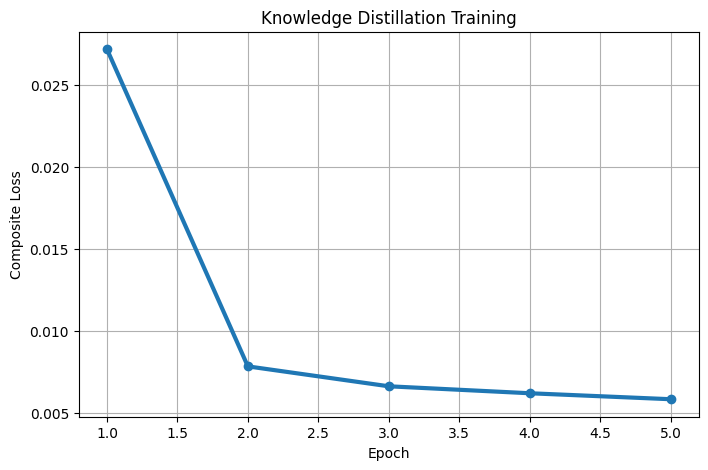

In [17]:
# Training Loss

plt.figure(figsize=(8,5))

plt.plot(

    range(

        1,

        EPOCHS+1

    ),

    train_losses,

    marker="o",

    linewidth=3

)

plt.xlabel("Epoch")

plt.ylabel("Composite Loss")

plt.title("Knowledge Distillation Training")

plt.grid(True)

plt.show()

In [18]:
# Save Model

MODEL_PATH = "student_clip_distilled.pth"

torch.save(

    student_model.state_dict(),

    MODEL_PATH

)

print("Model Saved Successfully")

print(MODEL_PATH)

Model Saved Successfully
student_clip_distilled.pth
